# Insurance Risk EDA (Task 1 Verification)
This notebook provides verifiable EDA work for insurance risk analytics.

## Coverage Checklist
- Descriptive statistics and schema inspection
- Missing-value analysis and explicit handling strategy
- Required visualizations for claims and premiums
- Loss-ratio analysis overall and by risk segments
- Temporal trends and summary insights

In [1]:
import sys
import os
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('..'))
import src.data_loader as data_loader_module
import src.eda_utilities as eda_utils_module
importlib.reload(data_loader_module)
importlib.reload(eda_utils_module)
from src.data_loader import load_insurance_data, check_data_quality
from src.eda_utilities import *

print("Setup complete!")

Setup complete!


In [2]:
# Load the data 
df = load_insurance_data('../data/MachineLearningRating_v3.txt')

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loading data from ../data/MachineLearningRating_v3.txt...
Loaded 1000098 rows, 52 columns

Derived metrics:
  - Loss Ratio mean: 0.216
  - Margin mean: R-2.96
  - Claim Frequency: 0.3%

Dataset shape: (1000098, 58)
Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType', 'Tota

In [3]:
# Initial data inspection
print("First 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())

First 5 rows:


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Month,Year,MonthName,LossRatio,Margin,HasClaim
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,21.929825,0.0,3,2015,March,0.0,21.929825,0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,21.929825,0.0,5,2015,May,0.0,21.929825,0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,0.000000,0.0,7,2015,July,0.0,0.000000,0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,512.848070,0.0,5,2015,May,0.0,512.848070,0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,0.000000,0.0,7,2015,July,0.0,0.000000,0



Data types:
UnderwrittenCoverID                  int64
PolicyID                             int64
TransactionMonth            datetime64[us]
IsVATRegistered                       bool
Citizenship                            str
LegalType                              str
Title                                  str
Language                               str
Bank                                   str
AccountType                            str
MaritalStatus                          str
Gender                                 str
Country                                str
Province                               str
PostalCode                           int64
MainCrestaZone                         str
SubCrestaZone                          str
ItemType                               str
mmcode                             float64
VehicleType                            str
RegistrationYear                     int64
make                                   str
Model                                  st

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,...,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,Month,Year,LossRatio,Margin,HasClaim
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,...,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,...,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01,5.905323e+00,2.014754e+03,2.163699e-01,-2.955694e+00,2.787727e-03
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,...,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04,1.000000e+00,2.013000e+03,-1.870012e+01,-3.928486e+05,0.000000e+00
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,...,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00,3.000000e+00,2.015000e+03,0.000000e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,...,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00,6.000000e+00,2.015000e+03,0.000000e+00,2.157687e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,...,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00,8.000000e+00,2.015000e+03,0.000000e+00,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,...,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05,1.200000e+01,2.015000e+03,2.553600e+03,6.528260e+04,1.000000e+00
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,...,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03,3.083934e+00,4.370288e-01,7.304735e+00,2.367137e+03,5.272531e-02


In [4]:
# Data quality check
quality_df = check_data_quality(df)
display(quality_df)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
display(missing_df[missing_df['Missing'] > 0])

,check,column,value,status
0,missing_values,Bank,14.59%,✅ OK
1,missing_values,AccountType,4.02%,✅ OK
2,missing_values,MaritalStatus,0.83%,✅ OK
3,missing_values,Gender,0.95%,✅ OK
4,missing_values,mmcode,0.06%,✅ OK
5,missing_values,VehicleType,0.06%,✅ OK
6,missing_values,make,0.06%,✅ OK
7,missing_values,Model,0.06%,✅ OK
8,missing_values,Cylinders,0.06%,✅ OK
9,missing_values,cubiccapacity,0.06%,✅ OK


,Missing,Percentage
Bank,145961,14.594670
AccountType,40232,4.022806
MaritalStatus,8259,0.825819
Gender,9536,0.953507
mmcode,552,0.055195
VehicleType,552,0.055195
make,552,0.055195
Model,552,0.055195
Cylinders,552,0.055195
cubiccapacity,552,0.055195


In [5]:
# Explicit missing-value handling plan (for transparent, reproducible preprocessing)
missing_profile = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_profile[missing_profile > 0].to_frame('missing_pct'))

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

imputation_plan = pd.DataFrame(
    {
        'column': numeric_cols + categorical_cols,
        'strategy': (['median'] * len(numeric_cols)) + (['mode'] * len(categorical_cols))
    }
)
display(imputation_plan.head(20))

,missing_pct
NumberOfVehiclesInFleet,100.000000
CrossBorder,99.930207
CustomValueEstimate,77.956560
Rebuilt,64.183810
Converted,64.183810
WrittenOff,64.183810
NewVehicle,15.327998
Bank,14.594670
AccountType,4.022806
Gender,0.953507


,column,strategy
0,UnderwrittenCoverID,median
1,PolicyID,median
2,PostalCode,median
3,mmcode,median
4,RegistrationYear,median
5,Cylinders,median
6,cubiccapacity,median
7,kilowatts,median
8,NumberOfDoors,median
9,CustomValueEstimate,median


## Missing-Value Strategy
The strategy below makes the treatment explicit for downstream modeling and reporting:
- Numeric features: median imputation (robust to outliers)
- Categorical features: mode imputation
- Date-derived features: left as null when source date is invalid
- Rows are not dropped by default to avoid sampling bias

In [6]:
# QUESTION 1: Overall Loss Ratio
total_claims = df['TotalClaims'].sum()
total_premium = df['TotalPremium'].sum()
loss_ratio = total_claims / total_premium

print("="*50)
print("OVERALL LOSS RATIO")
print("="*50)
print(f"Total Claims: R{total_claims:,.2f}")
print(f"Total Premium: R{total_premium:,.2f}")
print(f"Loss Ratio: {loss_ratio:.3f}")
print(f"\nInterpretation: For every R1 premium, R{loss_ratio:.2f} paid in claims")

OVERALL LOSS RATIO
Total Claims: R64,867,546.17
Total Premium: R61,911,562.70
Loss Ratio: 1.048

Interpretation: For every R1 premium, R1.05 paid in claims


## Loss-Ratio Analysis
This section quantifies portfolio profitability at overall and segment levels (province, vehicle type, gender, and time).


Loss Ratio by Province:
  Gauteng: 1.222
  KwaZulu-Natal: 1.083
  Western Cape: 1.059
  North West: 0.790
  Mpumalanga: 0.721
  Free State: 0.681
  Limpopo: 0.661
  Eastern Cape: 0.634
  Northern Cape: 0.283


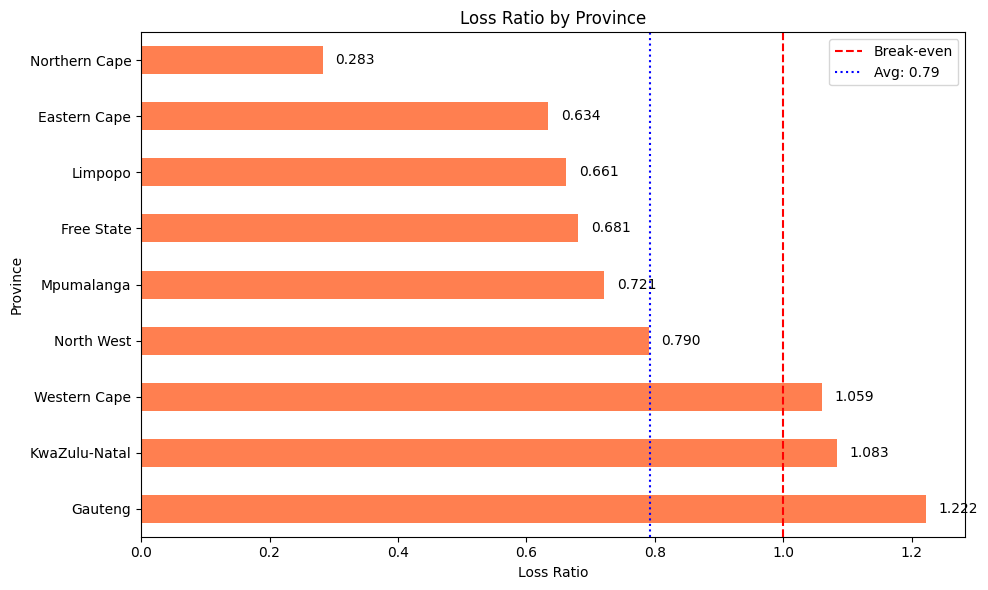

In [7]:
# Loss Ratio by Province
province_loss = df.groupby('Province').apply(
    lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()
).sort_values(ascending=False)

print("\nLoss Ratio by Province:")
for p, r in province_loss.items():
    print(f"  {p}: {r:.3f}")

fig = plot_loss_ratio_by_category(df, 'Province')
plt.show()


Loss Ratio by Vehicle Type:
  Heavy Commercial: 1.628
  Medium Commercial: 1.050
  Passenger Vehicle: 1.048
  Light Commercial: 0.232
  Bus: 0.137


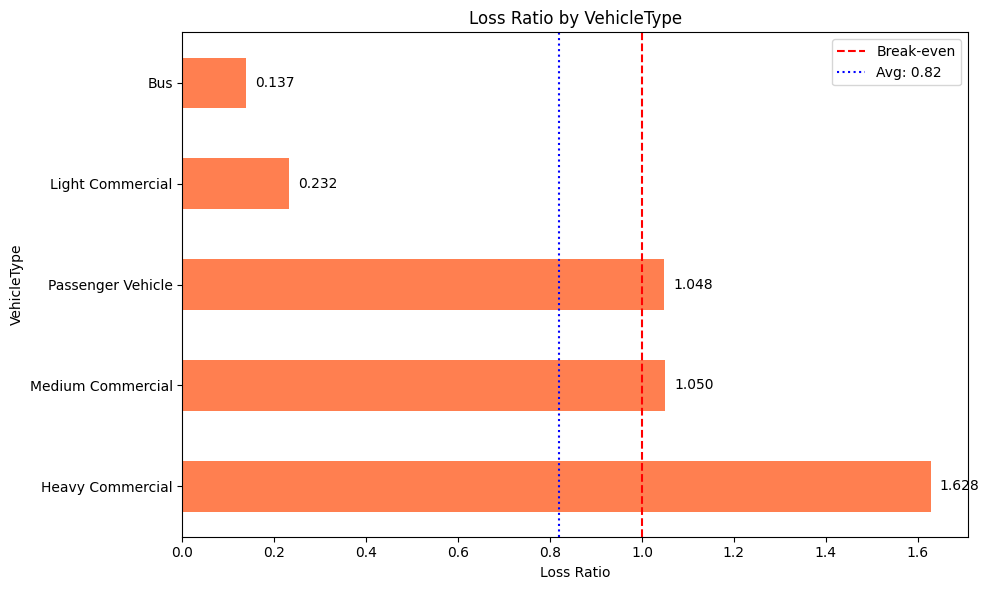

In [8]:
# Loss Ratio by Vehicle Type
if 'VehicleType' in df.columns:
    vehicle_loss = df.groupby('VehicleType').apply(
        lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()
    ).sort_values(ascending=False)
    
    print("\nLoss Ratio by Vehicle Type:")
    for v, r in vehicle_loss.items():
        print(f"  {v}: {r:.3f}")
    
    fig = plot_loss_ratio_by_category(df, 'VehicleType')
    plt.show()

In [9]:
# Loss Ratio by Gender
if 'Gender' in df.columns:
    gender_loss = df.groupby('Gender').apply(
        lambda x: x['TotalClaims'].sum() / x['TotalPremium'].sum()
    )
    
    print("\nLoss Ratio by Gender:")
    for g, r in gender_loss.items():
        print(f"  {g}: {r:.3f}")


Loss Ratio by Gender:
  Female: 0.822
  Male: 0.884
  Not specified: 1.059


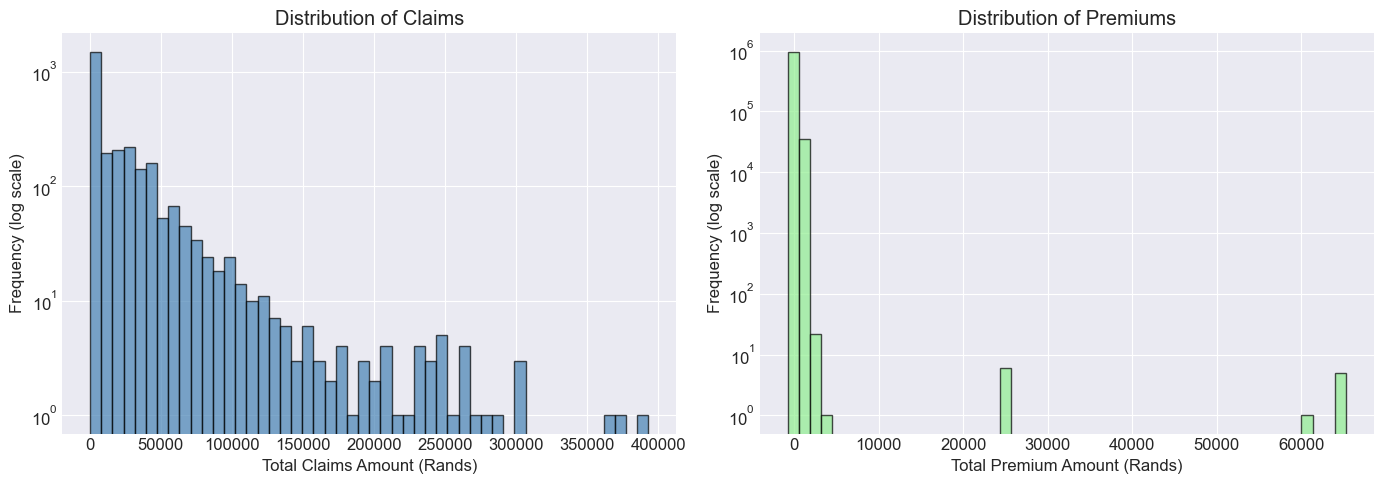

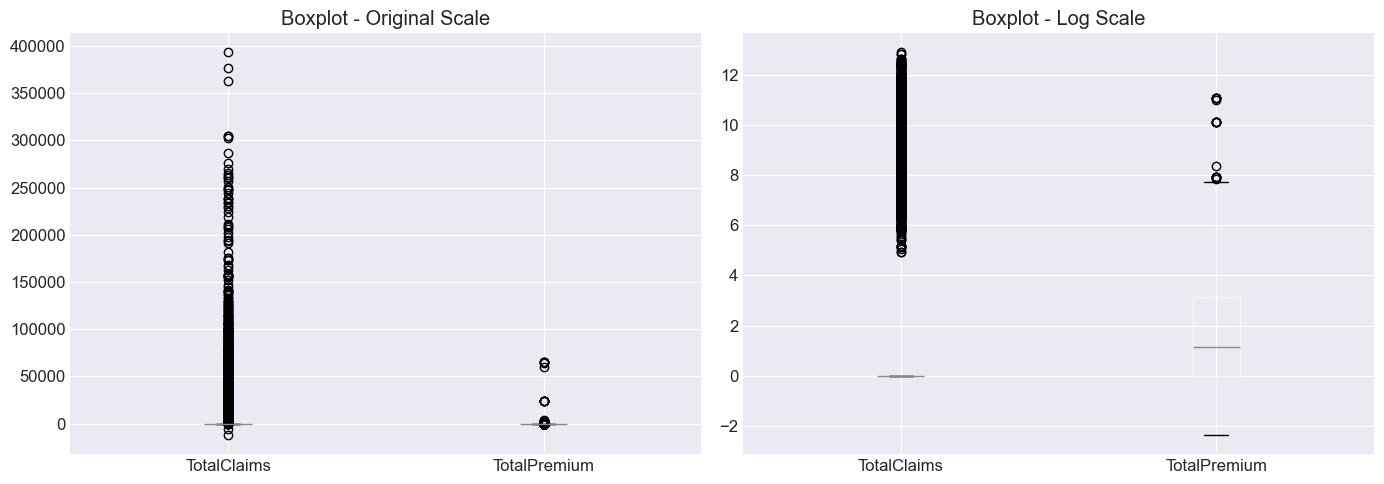


Outlier Analysis for TotalClaims
Lower bound: 0.00
Upper bound: 0.00
Number of outliers: 2793 (0.28%)

Outlier Analysis for TotalPremium
Lower bound: -32.89
Upper bound: 54.82
Number of outliers: 209042 (20.90%)


In [10]:
# QUESTION 2: Distributions and Outliers
setup_style()
fig1, fig2 = plot_claims_distribution(df)
plt.show()

claims_outliers = detect_outliers_iqr(df, 'TotalClaims')
premium_outliers = detect_outliers_iqr(df, 'TotalPremium')

## Required Visualizations
The next figures cover claim/premium distributions, outlier behavior, temporal trends, and multivariate relationships used for risk interpretation.

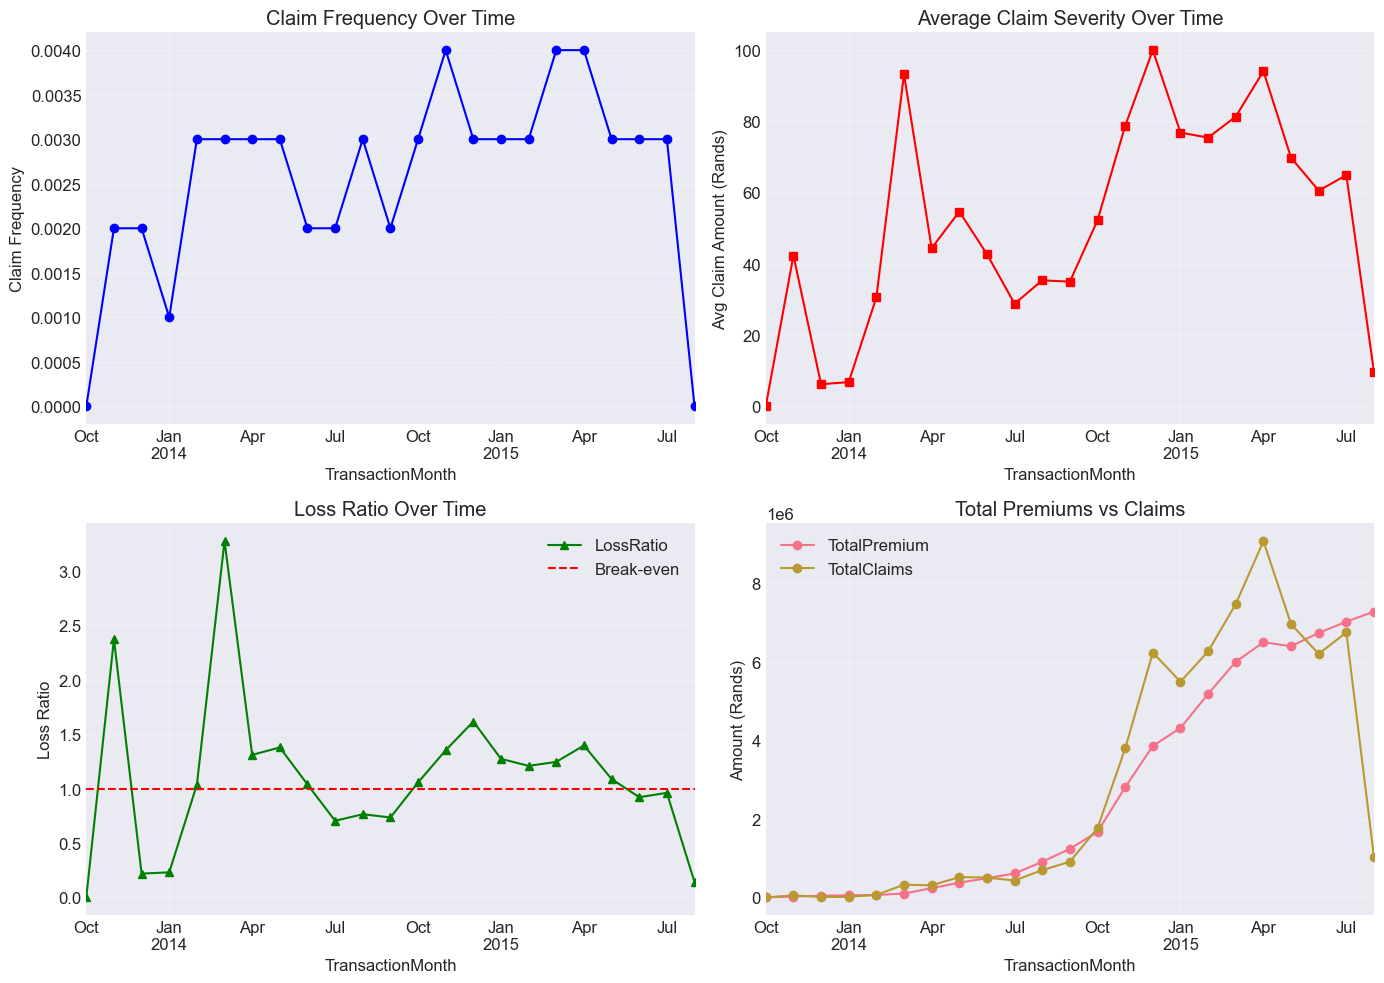


Monthly Summary:


,TotalClaims,TotalPremium,HasClaim
TransactionMonth,,,
2013-10,0.000000,371.063512,0.000000
2013-11,50585.078947,21307.467009,0.001672
2013-12,9283.385965,42484.748888,0.002007
2014-01,12436.859649,54085.196865,0.001095
2014-02,62989.307018,60788.436470,0.002910
2014-03,322785.021579,98577.193147,0.003462
2014-04,306863.592105,234274.337556,0.002891
2014-05,518042.736667,375911.724808,0.002952
2014-06,504536.396491,486219.395357,0.002368


In [11]:
# QUESTION 3: Temporal Trends
if 'TransactionMonth' in df.columns:
    fig = plot_temporal_trends(df)
    plt.show()
    
    # Monthly claims summary
    monthly = df.groupby(df['TransactionMonth'].dt.to_period('M')).agg({
        'TotalClaims': 'sum',
        'TotalPremium': 'sum',
        'HasClaim': 'mean'
    })
    print("\nMonthly Summary:")
    display(monthly.head(10))

TOP 10 MAKES - HIGHEST CLAIMS:


,Avg_Claim,Total_Claims,Policy_Count
make,,,
SUZUKI,419.63,171210.89,408
JMC,191.68,23002.18,120
HYUNDAI,174.22,453307.94,2602
MARCOPOLO,156.79,7996.54,51
AUDI,137.84,1021003.71,7407
POLARSUN,134.04,125197.84,934
B.A.W,132.93,287137.47,2160
FIAT,108.63,106887.63,984
BMW,90.56,481497.15,5317



BOTTOM 10 MAKES - LOWEST CLAIMS:


,Avg_Claim,Total_Claims,Policy_Count
make,,,
HINO,0.0,0.0,242
JINBEI,0.0,0.0,60
LEXUS,0.0,0.0,336
PROTON,0.0,0.0,198
PEUGEOT,0.0,0.0,463
OPEL,0.0,0.0,147
RENAULT,0.0,0.0,156
SCANIA,0.0,0.0,342
TATA,0.0,0.0,381


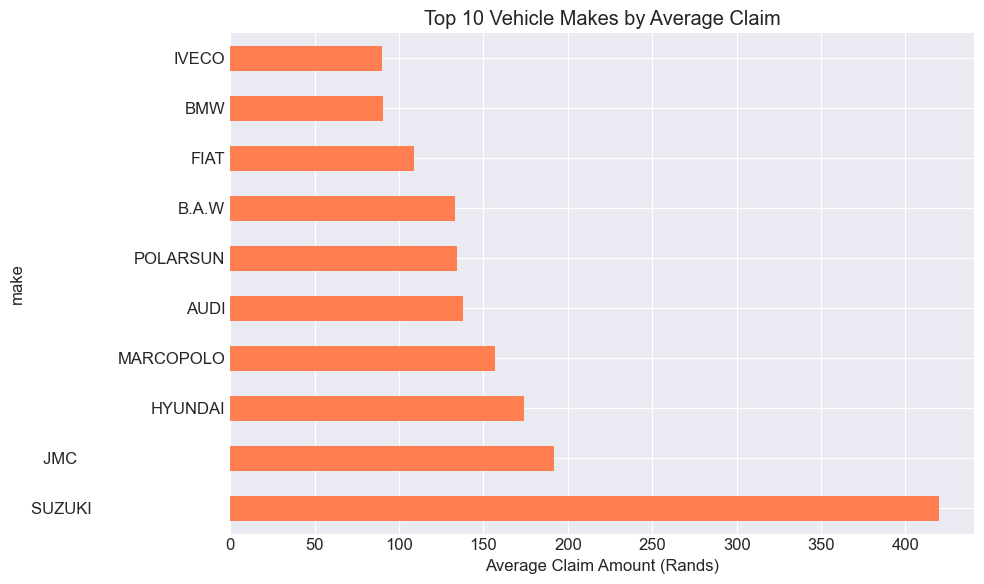

In [12]:
# QUESTION 4: Vehicle Makes Analysis
make_col = 'Make' if 'Make' in df.columns else 'make' if 'make' in df.columns else None
if make_col:
    make_claims = df.groupby(make_col).agg({
        'TotalClaims': ['mean', 'sum', 'count']
    }).round(2)
    make_claims.columns = ['Avg_Claim', 'Total_Claims', 'Policy_Count']
    make_claims = make_claims.sort_values('Avg_Claim', ascending=False)
    
    print("TOP 10 MAKES - HIGHEST CLAIMS:")
    display(make_claims.head(10))
    
    print("\nBOTTOM 10 MAKES - LOWEST CLAIMS:")
    display(make_claims.tail(10))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    make_claims.head(10)['Avg_Claim'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Average Claim Amount (Rands)')
    ax.set_title('Top 10 Vehicle Makes by Average Claim')
    plt.tight_layout()
    plt.show()

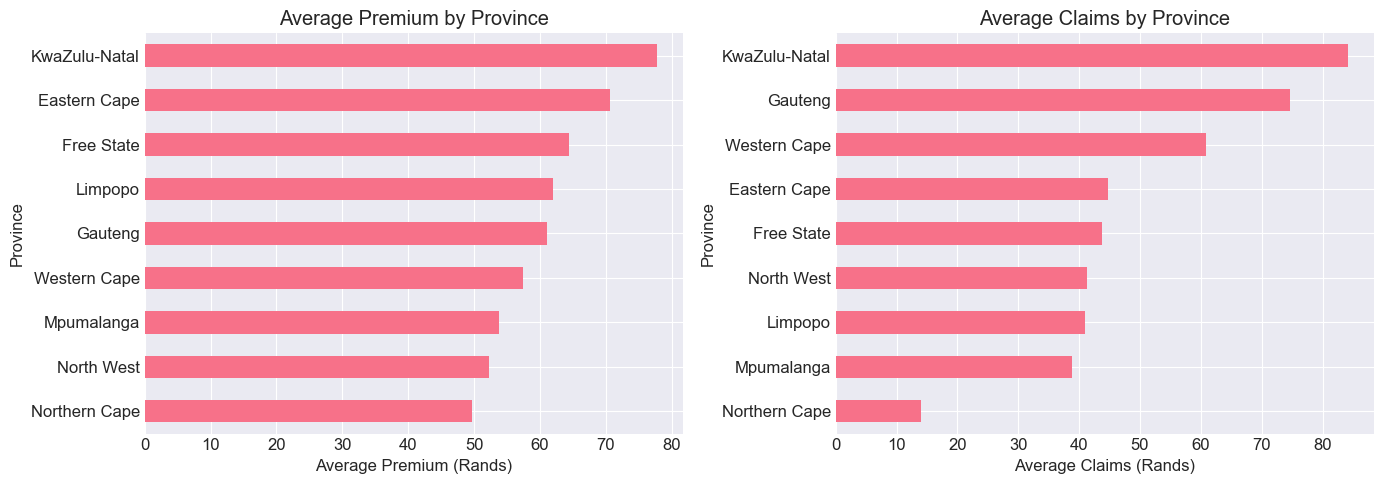

In [13]:
# Geographic Trends - Premium by Province
if 'Province' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df.groupby('Province')['TotalPremium'].mean().sort_values().plot(kind='barh', ax=axes[0])
    axes[0].set_title('Average Premium by Province')
    axes[0].set_xlabel('Average Premium (Rands)')
    
    df.groupby('Province')['TotalClaims'].mean().sort_values().plot(kind='barh', ax=axes[1])
    axes[1].set_title('Average Claims by Province')
    axes[1].set_xlabel('Average Claims (Rands)')
    
    plt.tight_layout()
    plt.show()

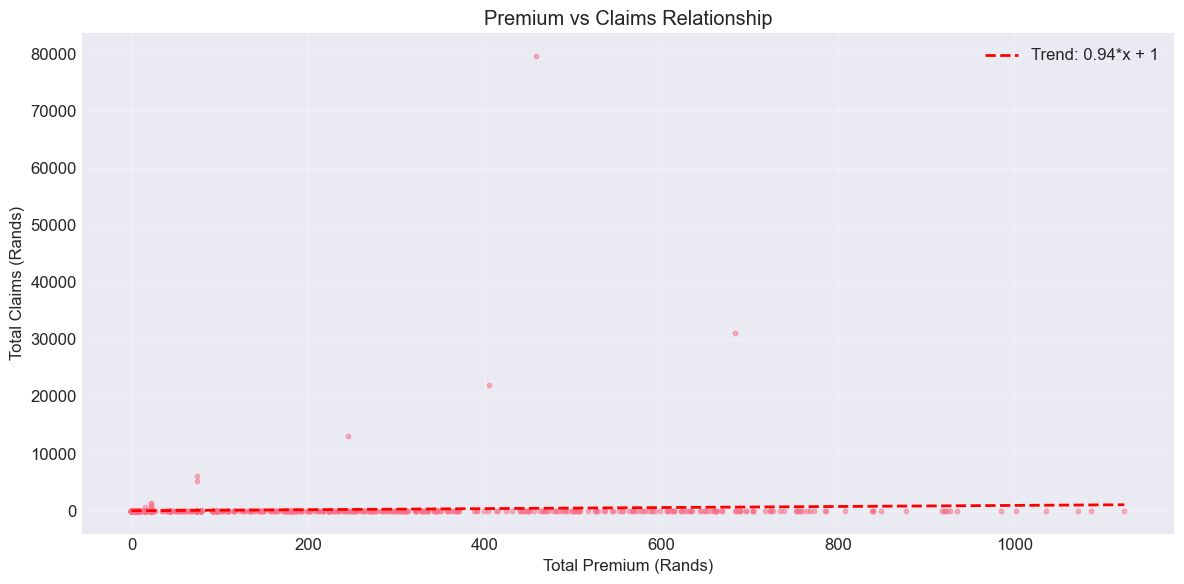

Correlation: 0.122


In [14]:
# Creative Plot 1: Premium vs Claims with trend line
fig, ax = plt.subplots(figsize=(12, 6))

sample_df = df.sample(min(3000, len(df)))
ax.scatter(sample_df['TotalPremium'], sample_df['TotalClaims'], alpha=0.5, s=10)

# Add trend line
z = np.polyfit(sample_df['TotalPremium'], sample_df['TotalClaims'], 1)
p = np.poly1d(z)
ax.plot(sample_df['TotalPremium'].sort_values(), 
        p(sample_df['TotalPremium'].sort_values()), 
        "r--", linewidth=2, label=f'Trend: {z[0]:.2f}*x + {z[1]:.0f}')

ax.set_xlabel('Total Premium (Rands)')
ax.set_ylabel('Total Claims (Rands)')
ax.set_title('Premium vs Claims Relationship')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation: {df['TotalPremium'].corr(df['TotalClaims']):.3f}")

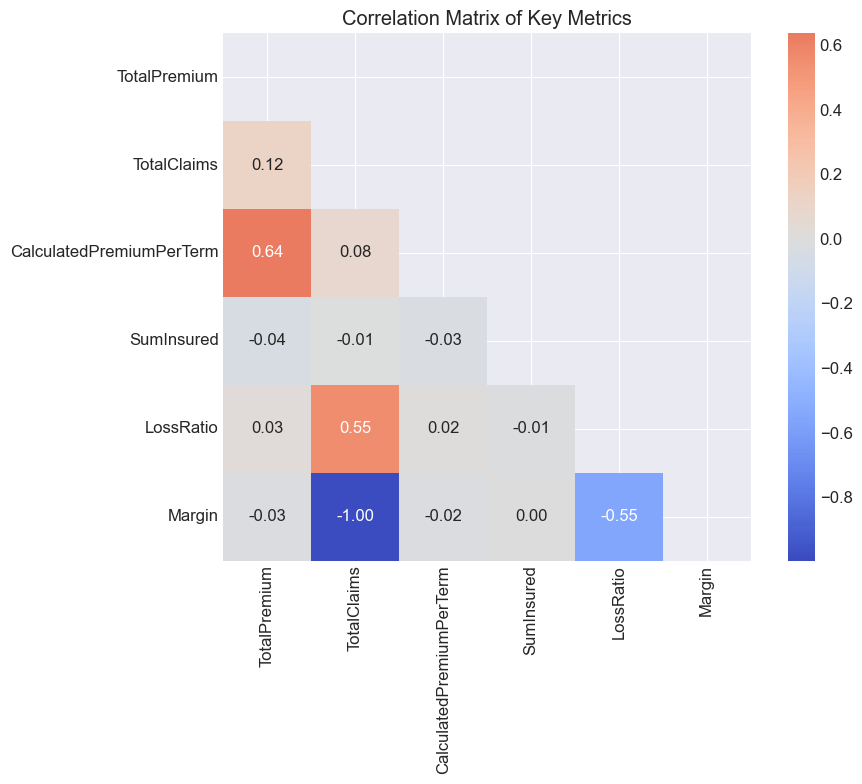

In [15]:
# Creative Plot 2: Correlation Heatmap
numeric_cols = ['TotalPremium', 'TotalClaims', 'CalculatedPremiumPerTerm', 
                'SumInsured', 'LossRatio', 'Margin']
available = [c for c in numeric_cols if c in df.columns]

if len(available) > 1:
    corr_matrix = df[available].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', 
                center=0, fmt='.2f', square=True, ax=ax)
    ax.set_title('Correlation Matrix of Key Metrics')
    plt.tight_layout()
    plt.show()

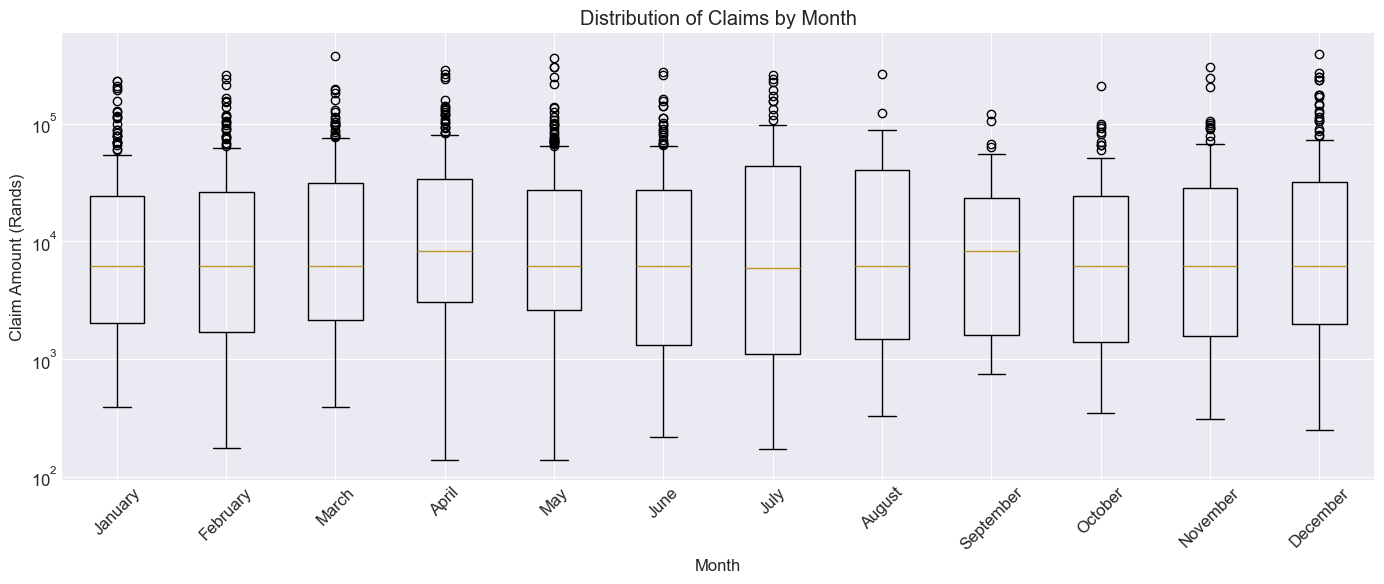

In [16]:
# Creative Plot 3: Claims Distribution by Month (Boxplot)
if 'TransactionMonth' in df.columns and 'HasClaim' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    df['MonthName'] = df['TransactionMonth'].dt.month_name()
    months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']
    
    claims_by_month = [df[df['MonthName'] == m]['TotalClaims'] for m in months_order if m in df['MonthName'].values]
    
    bp = ax.boxplot([c[c > 0] for c in claims_by_month if len(c[c > 0]) > 0], 
                    labels=[m for m in months_order if m in df['MonthName'].values])
    ax.set_xlabel('Month')
    ax.set_ylabel('Claim Amount (Rands)')
    ax.set_title('Distribution of Claims by Month')
    ax.set_yscale('log')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [17]:
# FINAL SUMMARY
print("="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

print(f"\n1. Overall Loss Ratio: {loss_ratio:.3f}")
print(f"   → Portfolio is {'UNPROFITABLE' if loss_ratio > 0.9 else 'PROFITABLE'}")

if 'province_loss' in locals():
    print(f"\n2. Geographic Risk:")
    print(f"   → Highest: {province_loss.index[0]} ({province_loss.iloc[0]:.3f})")
    print(f"   → Lowest: {province_loss.index[-1]} ({province_loss.iloc[-1]:.3f})")

if 'vehicle_loss' in locals():
    print(f"\n3. Vehicle Risk:")
    print(f"   → Highest risk: {vehicle_loss.index[0]} ({vehicle_loss.iloc[0]:.3f})")

print(f"\n4. Outliers: {len(claims_outliers)/len(df)*100:.1f}% of claims are outliers")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
print("✓ Focus marketing on lowest risk provinces")
print("✓ Review pricing for highest risk vehicle types")
print("✓ Investigate seasonal patterns for premium adjustments")
print("✓ Consider removing extreme outliers for modeling")

KEY INSIGHTS FROM EDA

1. Overall Loss Ratio: 1.048
   → Portfolio is UNPROFITABLE

2. Geographic Risk:
   → Highest: Gauteng (1.222)
   → Lowest: Northern Cape (0.283)

3. Vehicle Risk:
   → Highest risk: Heavy Commercial (1.628)

4. Outliers: 0.3% of claims are outliers

RECOMMENDATIONS
✓ Focus marketing on lowest risk provinces
✓ Review pricing for highest risk vehicle types
✓ Investigate seasonal patterns for premium adjustments
✓ Consider removing extreme outliers for modeling
